## Бельдинова Мария
## гр. 6133-010402D


In [1]:
import numpy as np
import time
import math
import pandas as pd
from numba import cuda
import matplotlib.pyplot as plt

In [2]:
import warnings
from numba.core.errors import NumbaPerformanceWarning

warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

##Проверка подключения к GPU:

In [3]:
# Проверка GPU
assert cuda.is_available(), "CUDA GPU не найдено"

## Основные функции для CPU и GPU

In [4]:
def mult_matr_cpu(A, B, block_size=32):
    n = A.shape[0]
    C = np.zeros((n, n), dtype=np.float32)

    start_time = time.time()

    for i in range(0, n, block_size):
        for j in range(0, n, block_size):
            for k in range(0, n, block_size):
                for ii in range(i, min(i+block_size, n)):
                    for jj in range(j, min(j+block_size, n)):
                        s = 0.0
                        for kk in range(k, min(k+block_size, n)):
                            s += A[ii, kk] * B[kk, jj]
                        C[ii, jj] += s

    end_time = time.time()
    return C, end_time - start_time

##Функция для проверки результатов подсчета умножения матриц, выбрана точность 1е-5

In [5]:
def validate_result(C, C_ref):
    return np.allclose(C, C_ref, atol=1e-6)

In [6]:
matrix_sizes = [100, 200, 400, 800, 1600]
results = []

## Основной вычислительный процесс

In [9]:
def mult_matr_gpu(A, B, num_runs=3):
    A_device = cuda.to_device(A)
    B_device = cuda.to_device(B)
    C_device = cuda.device_array((A.shape[0], B.shape[1]), dtype=np.float32)

    threads_per_block = (16, 16)
    blocks_per_grid_x = math.ceil(A.shape[0] / threads_per_block[0])
    blocks_per_grid_y = math.ceil(B.shape[1] / threads_per_block[1])
    blocks_per_grid = (blocks_per_grid_x, blocks_per_grid_y)

    mat_mul[blocks_per_grid, threads_per_block](A_device, B_device, C_device)
    cuda.synchronize()

    times = []
    for _ in range(num_runs):
        start = time.perf_counter()
        mat_mul[blocks_per_grid, threads_per_block](A_device, B_device, C_device)
        cuda.synchronize()
        end = time.perf_counter()
        times.append(end - start)

    C = C_device.copy_to_host()
    return C, np.mean(times)

In [10]:
@cuda.jit
def mat_mul(A, B, C):
    i, j = cuda.grid(2)
    if i < A.shape[0] and j < B.shape[1]:
        temp_sum = 0
        for k in range(A.shape[1]):
            temp_sum += A[i, k] * B[k, j]
        C[i, j] = temp_sum

In [13]:
matrix_sizes = [128, 256, 512]
results = []

for size in matrix_sizes:
    print(f"Тестовый размер --> {size}")

    A = np.random.rand(size, size).astype(np.float32)
    B = np.random.rand(size, size).astype(np.float32)

    # Запуск на CPU
    C_cpu, time_cpu = mult_matr_cpu(A, B)
    # Запуск на GPU
    C_gpu, time_gpu = mult_matr_gpu(A, B)

    C_reference = np.dot(A, B)
    is_cpu_correct = validate_result(C_cpu, C_reference)
    is_gpu_correct = validate_result(C_gpu, C_reference)

    speedup = time_cpu / time_gpu if time_gpu > 0 else None

    results.append({
        'Размер': size,
        'Время CPU': time_cpu,
        'Время GPU': time_gpu,
        'Ускорение': speedup,
        'Корректность CPU': is_cpu_correct,
        'Корректность GPU': is_gpu_correct
    })

df = pd.DataFrame(results)
print("Результаты эксперимента:")
print(df)

Тестовый размер --> 128
Тестовый размер --> 256
Тестовый размер --> 512
Результаты эксперимента:
   Размер  Время CPU  Время GPU    Ускорение  Корректность CPU  \
0     128   0.795360   0.000190  4191.443037              True   
1     256   8.634998   0.000974  8867.036607              True   
2     512  55.678021   0.006796  8193.323004              True   

   Корректность GPU  
0              True  
1              True  
2              True  


## Собираем результаты

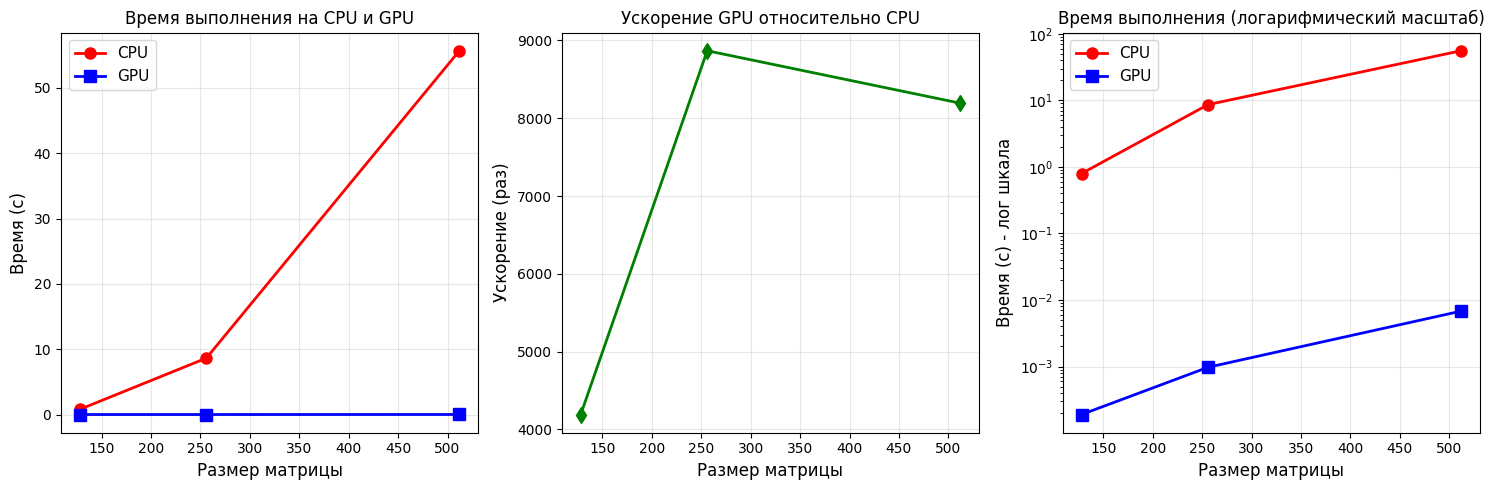

In [14]:
sizes = [r['Размер'] for r in results]
cpu_times = [r['Время CPU'] for r in results]
gpu_times = [r['Время GPU'] for r in results]
speedups = [r['Ускорение'] for r in results]

plt.figure(figsize=(15,5))

# График 1: Время выполнения
plt.subplot(1,3,1)
plt.plot(sizes, cpu_times, 'o-', label='CPU', color='red', linewidth=2, markersize=8)
plt.plot(sizes, gpu_times, 's-', label='GPU', color='blue', linewidth=2, markersize=8)
plt.xlabel('Размер матрицы', fontsize=12)
plt.ylabel('Время (с)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.title('Время выполнения на CPU и GPU', fontsize=12)

# График 2: Ускорение
plt.subplot(1,3,2)
plt.plot(sizes, speedups, 'd-', color='green', linewidth=2, markersize=8)
plt.xlabel('Размер матрицы', fontsize=12)
plt.ylabel('Ускорение (раз)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.title('Ускорение GPU относительно CPU', fontsize=12)

# График 3: Логарифмический масштаб (НОВЫЙ!)
plt.subplot(1,3,3)
plt.semilogy(sizes, cpu_times, 'o-', label='CPU', color='red', linewidth=2, markersize=8)
plt.semilogy(sizes, gpu_times, 's-', label='GPU', color='blue', linewidth=2, markersize=8)
plt.xlabel('Размер матрицы', fontsize=12)
plt.ylabel('Время (с) - лог шкала', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.title('Время выполнения (логарифмический масштаб)', fontsize=12)

plt.tight_layout()
plt.savefig('my_matrix_mul_results.png', dpi=150)
plt.show()

## CPU и GPU

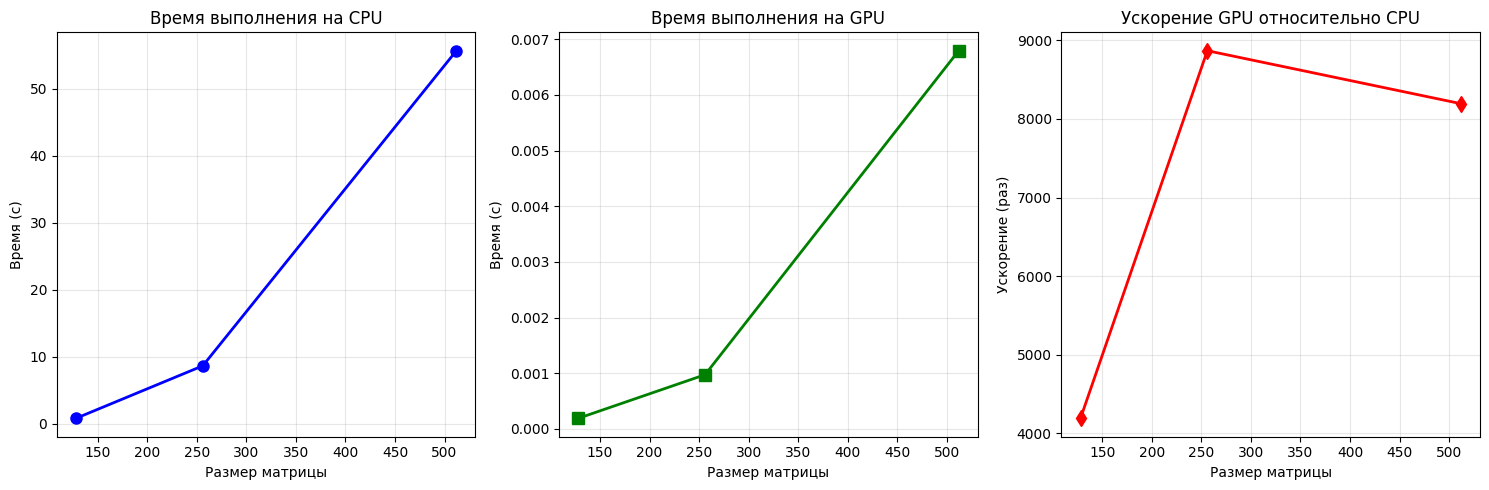

In [15]:
sizes = [r['Размер'] for r in results]
cpu_times = [r['Время CPU'] for r in results]
gpu_times = [r['Время GPU'] for r in results]
speedups = [r['Ускорение'] for r in results]

plt.figure(figsize=(15, 5))

# График 1: CPU время
plt.subplot(1, 3, 1)
plt.plot(sizes, cpu_times, 'o-', color='blue', linewidth=2, markersize=8)
plt.xlabel('Размер матрицы')
plt.ylabel('Время (с)')
plt.title('Время выполнения на CPU')
plt.grid(True, alpha=0.3)

# График 2: GPU время
plt.subplot(1, 3, 2)
plt.plot(sizes, gpu_times, 's-', color='green', linewidth=2, markersize=8)
plt.xlabel('Размер матрицы')
plt.ylabel('Время (с)')
plt.title('Время выполнения на GPU')
plt.grid(True, alpha=0.3)

# График 3: Ускорение (НОВЫЙ!)
plt.subplot(1, 3, 3)
plt.plot(sizes, speedups, 'd-', color='red', linewidth=2, markersize=8)
plt.xlabel('Размер матрицы')
plt.ylabel('Ускорение (раз)')
plt.title('Ускорение GPU относительно CPU')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('my_results.png', dpi=150)
plt.show()

